In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

Loading in the data and interpolate missing data

In [2]:
data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

Plotting the daily data

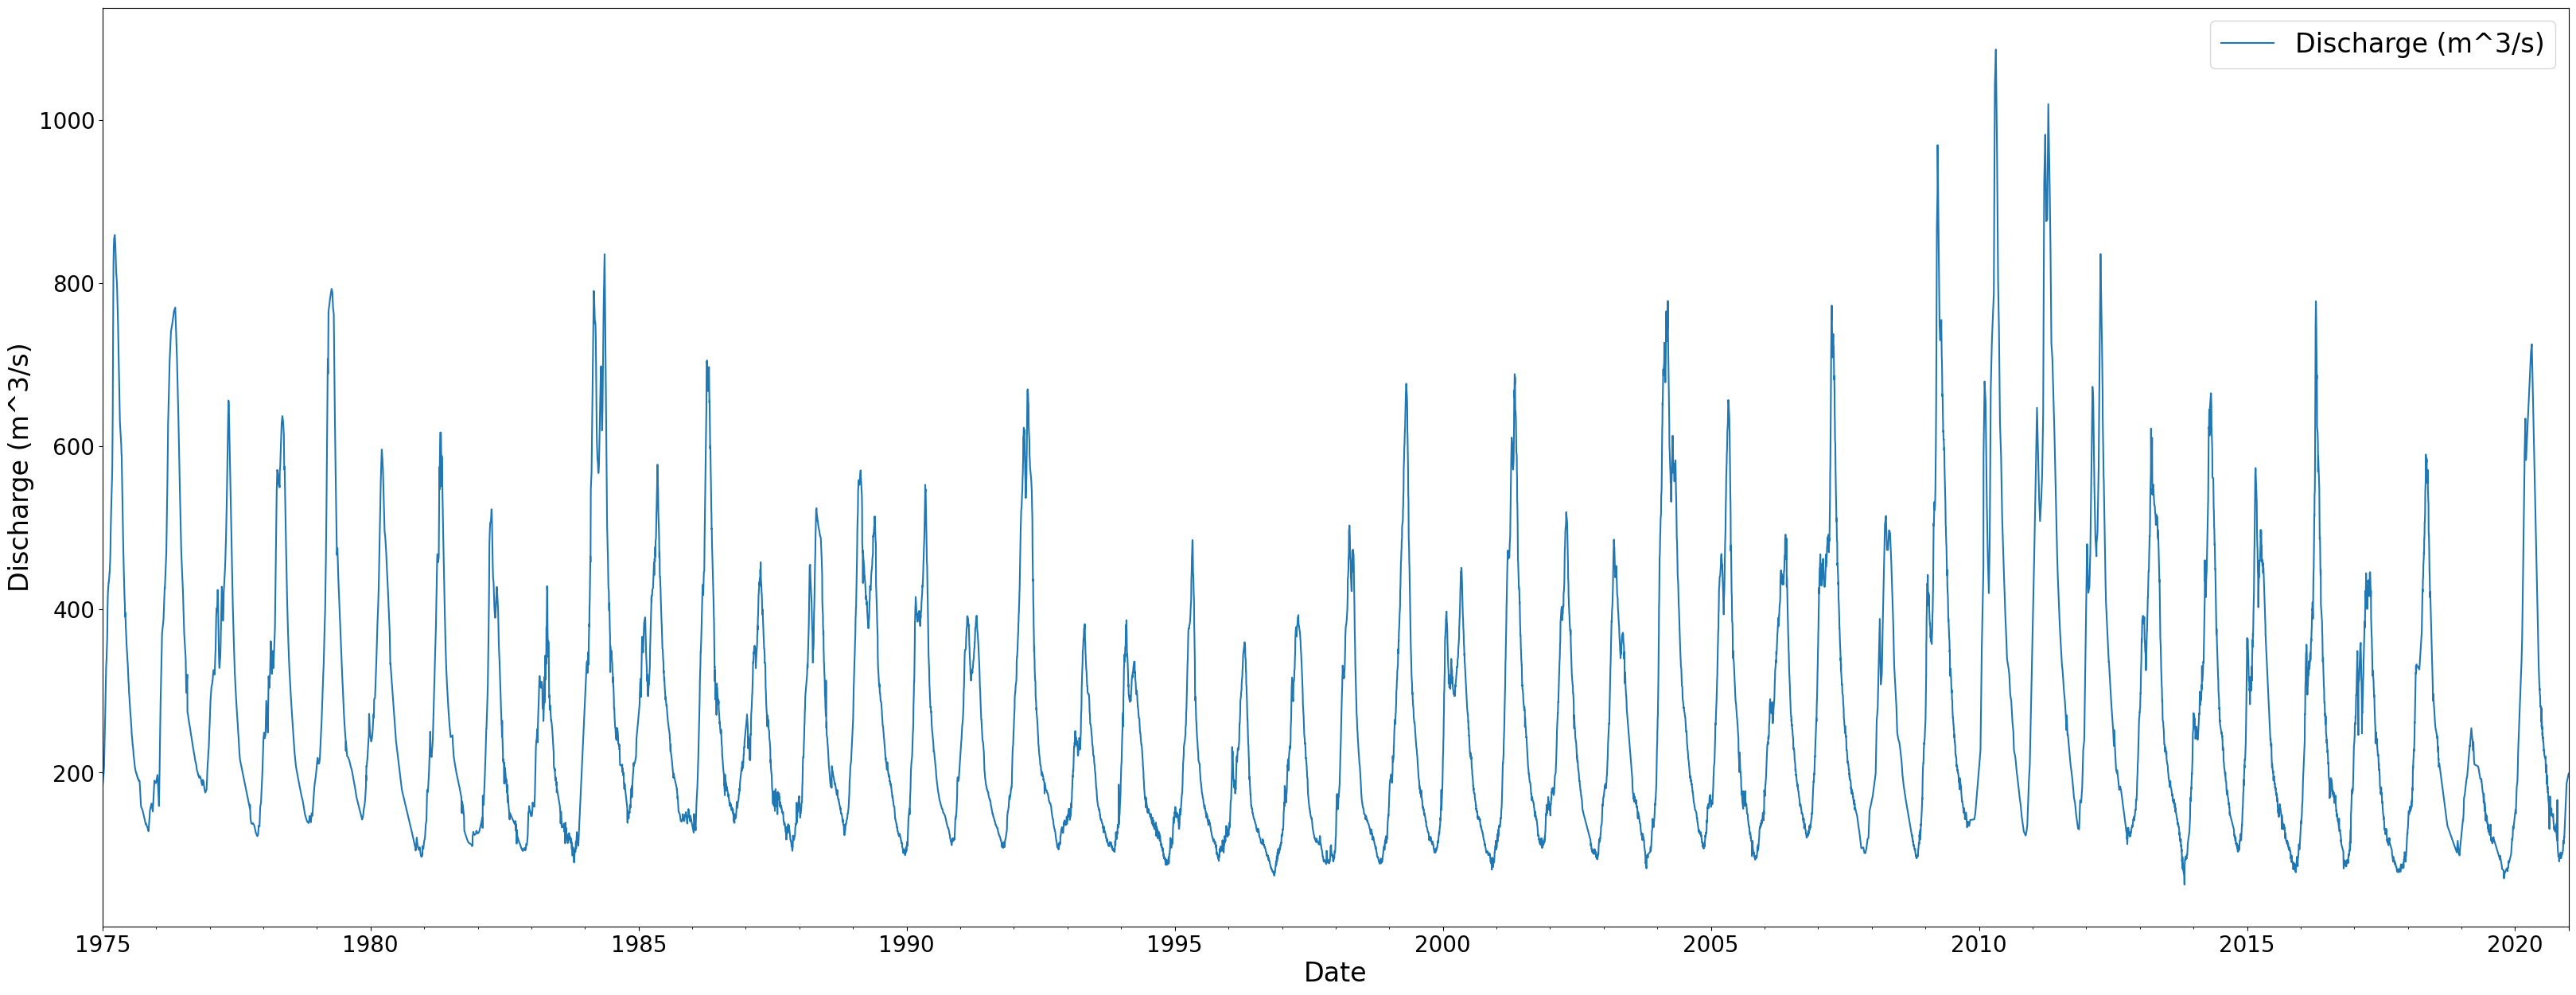

In [3]:
fig, ax = plt.subplots(figsize=(40, 15))
data_daily.plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.legend(fontsize=24);

Yearly max discharge

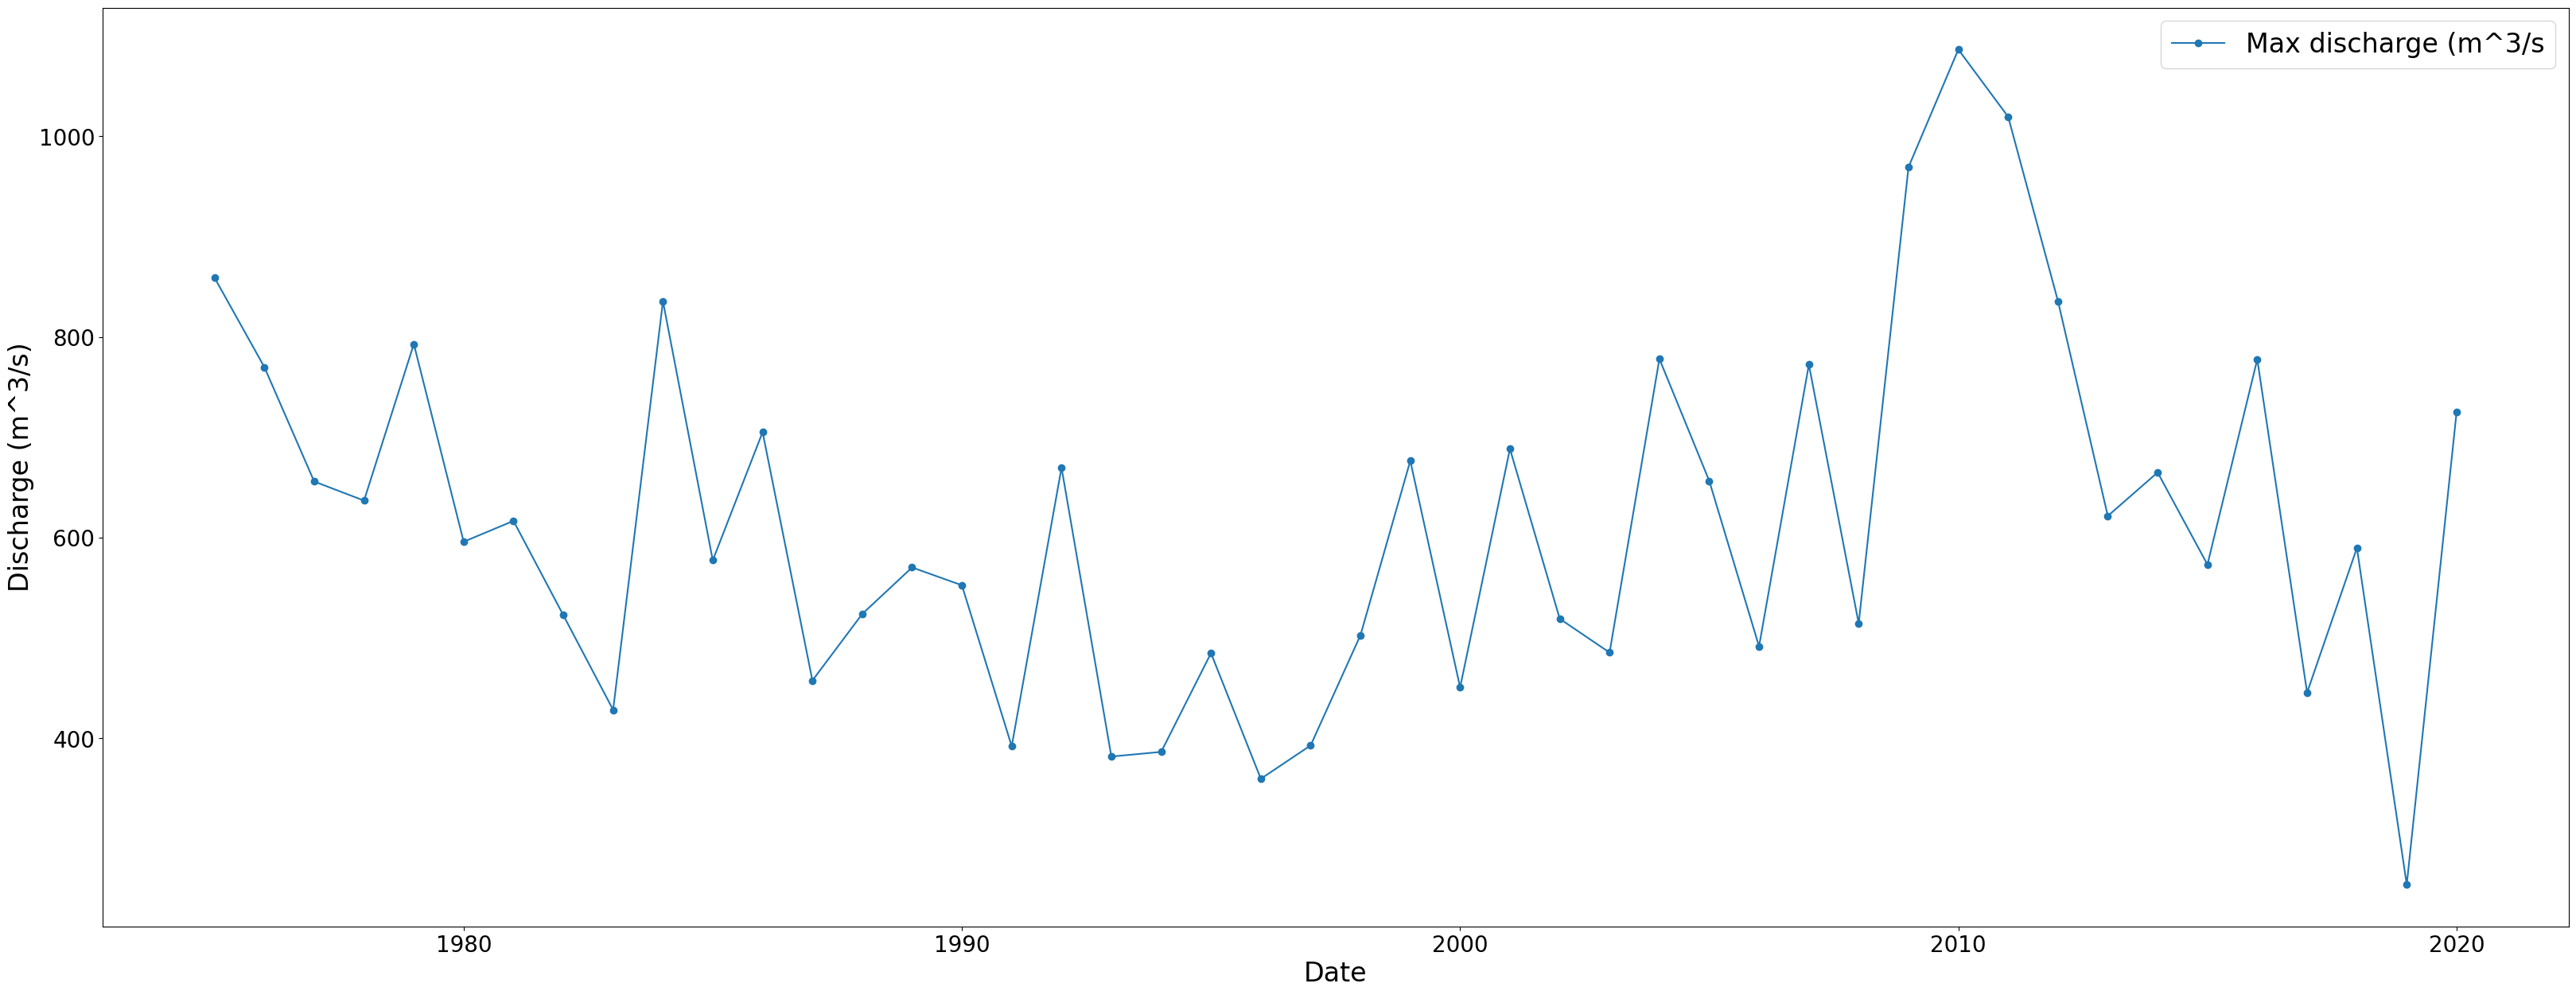

In [4]:
yearly_max = data_daily.resample('YE').max()
yearly_max.index = yearly_max.index.year
yearly_max.columns = ['Max discharge (m^3/s']

fig, ax = plt.subplots(figsize=(40, 15))
yearly_max.plot(ax=ax, marker='o')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.legend(fontsize=24);

Yearly volume

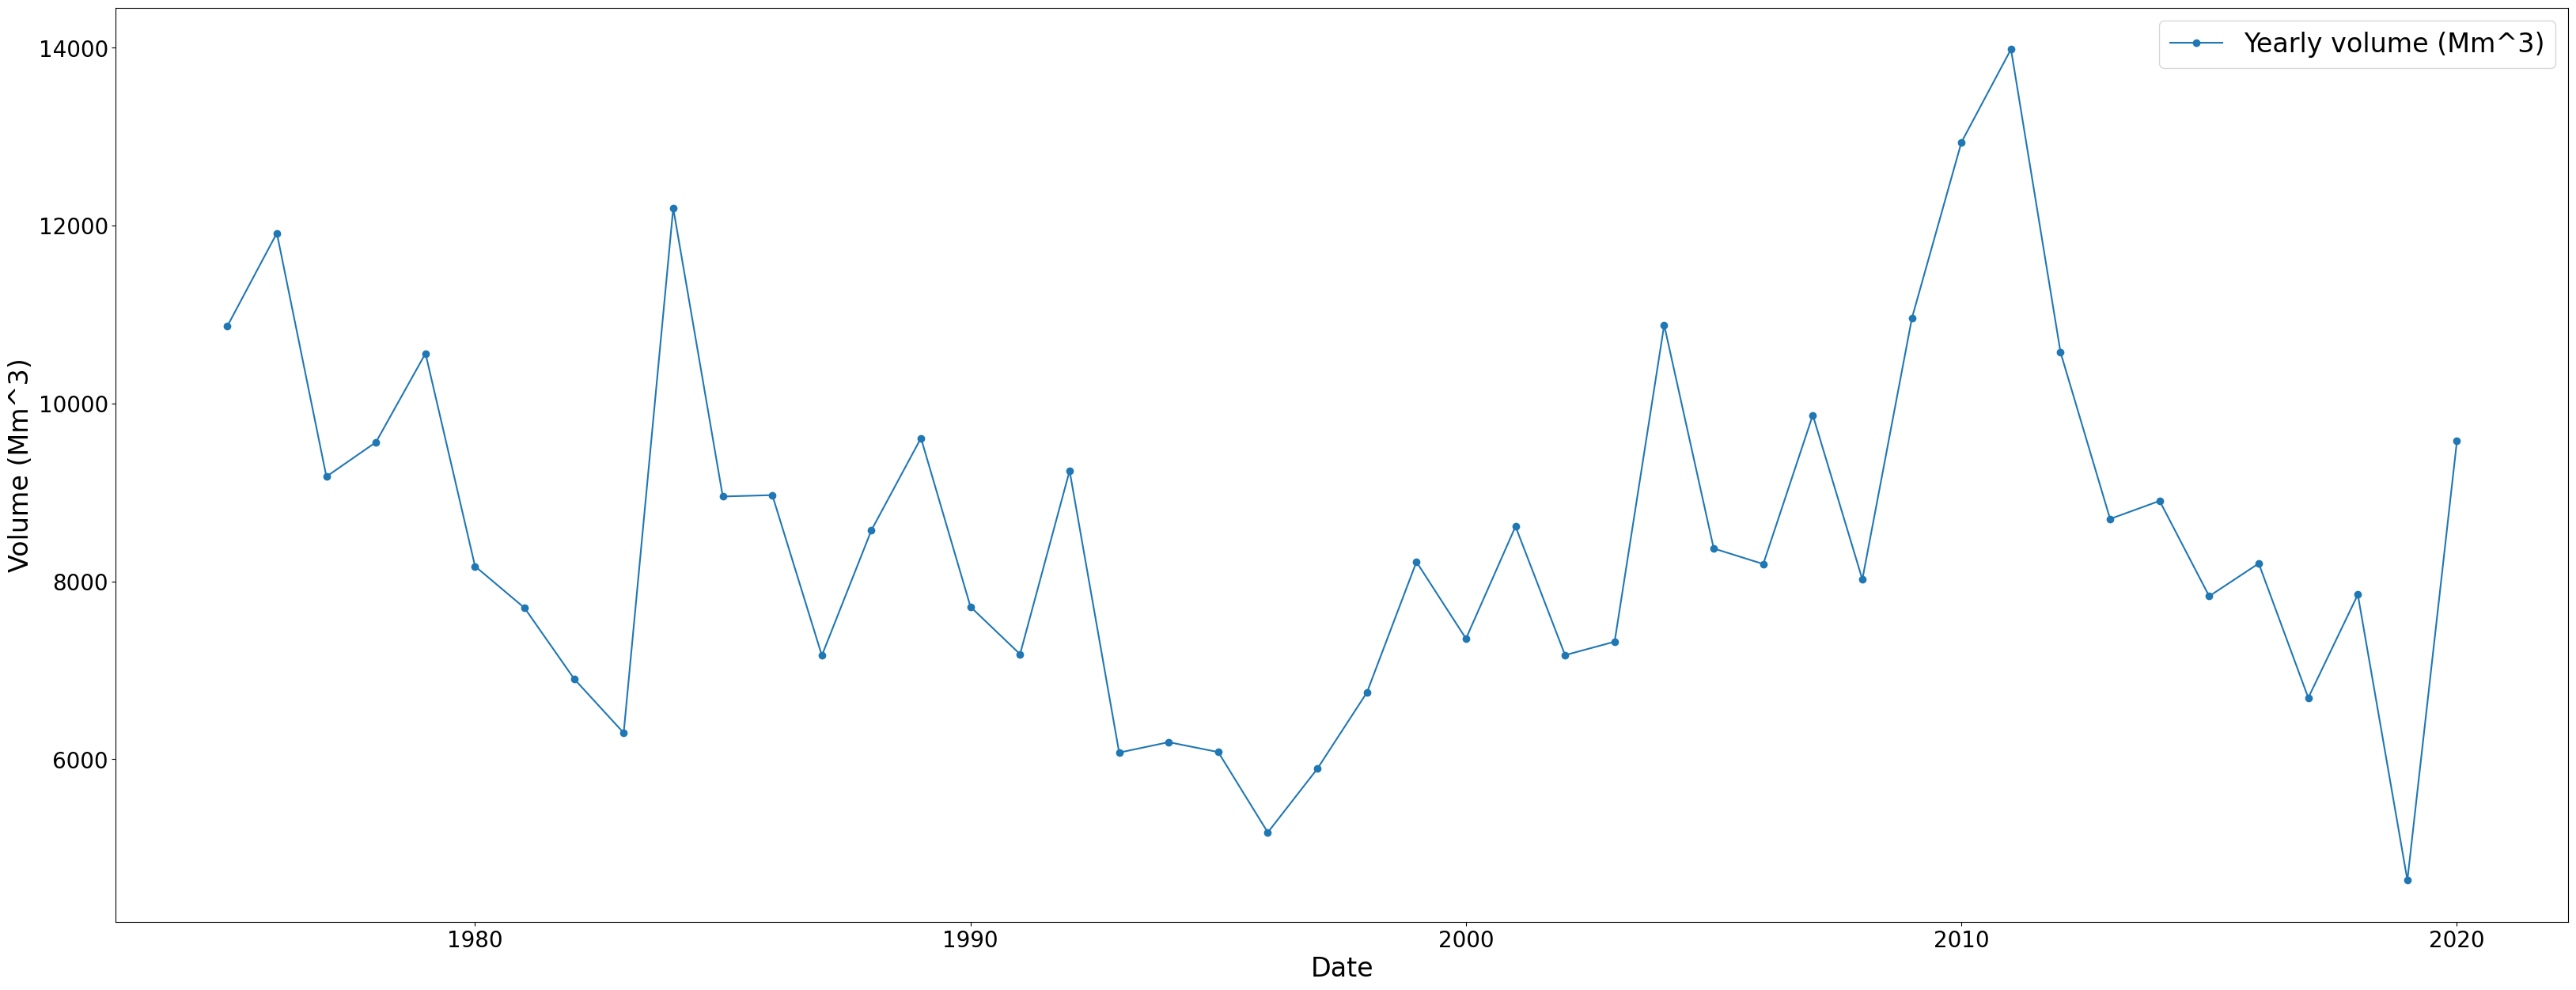

In [5]:
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.index = yearly_volume.index.year
yearly_volume.columns = ['Yearly volume (Mm^3)']

fig, ax = plt.subplots(figsize=(40, 15))
yearly_volume.plot(ax=ax, marker='o')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24);

Determine months that are important to flooding

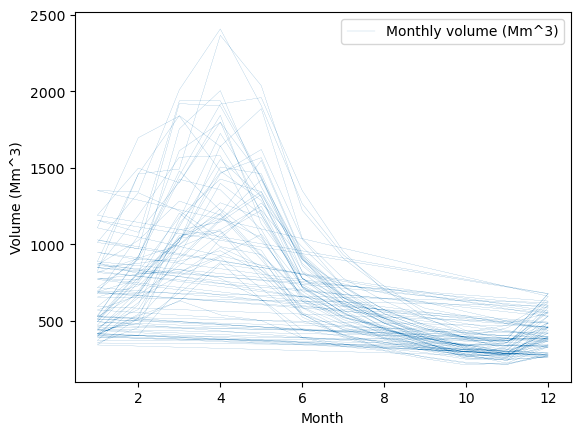

In [6]:
data_monthly = (data_daily * 3600 * 24).resample('ME').sum() / 1e6
data_monthly.index = data_monthly.index.month
data_monthly.columns = ['Monthly volume (Mm^3)']

fig, ax = plt.subplots()
data_monthly.plot(ax=ax, linewidth=0.1)
plt.xticks()
plt.yticks()
ax.set_xlabel("Month")
ax.set_ylabel("Volume (Mm^3)")
plt.legend();

Volume between months 2 and 7

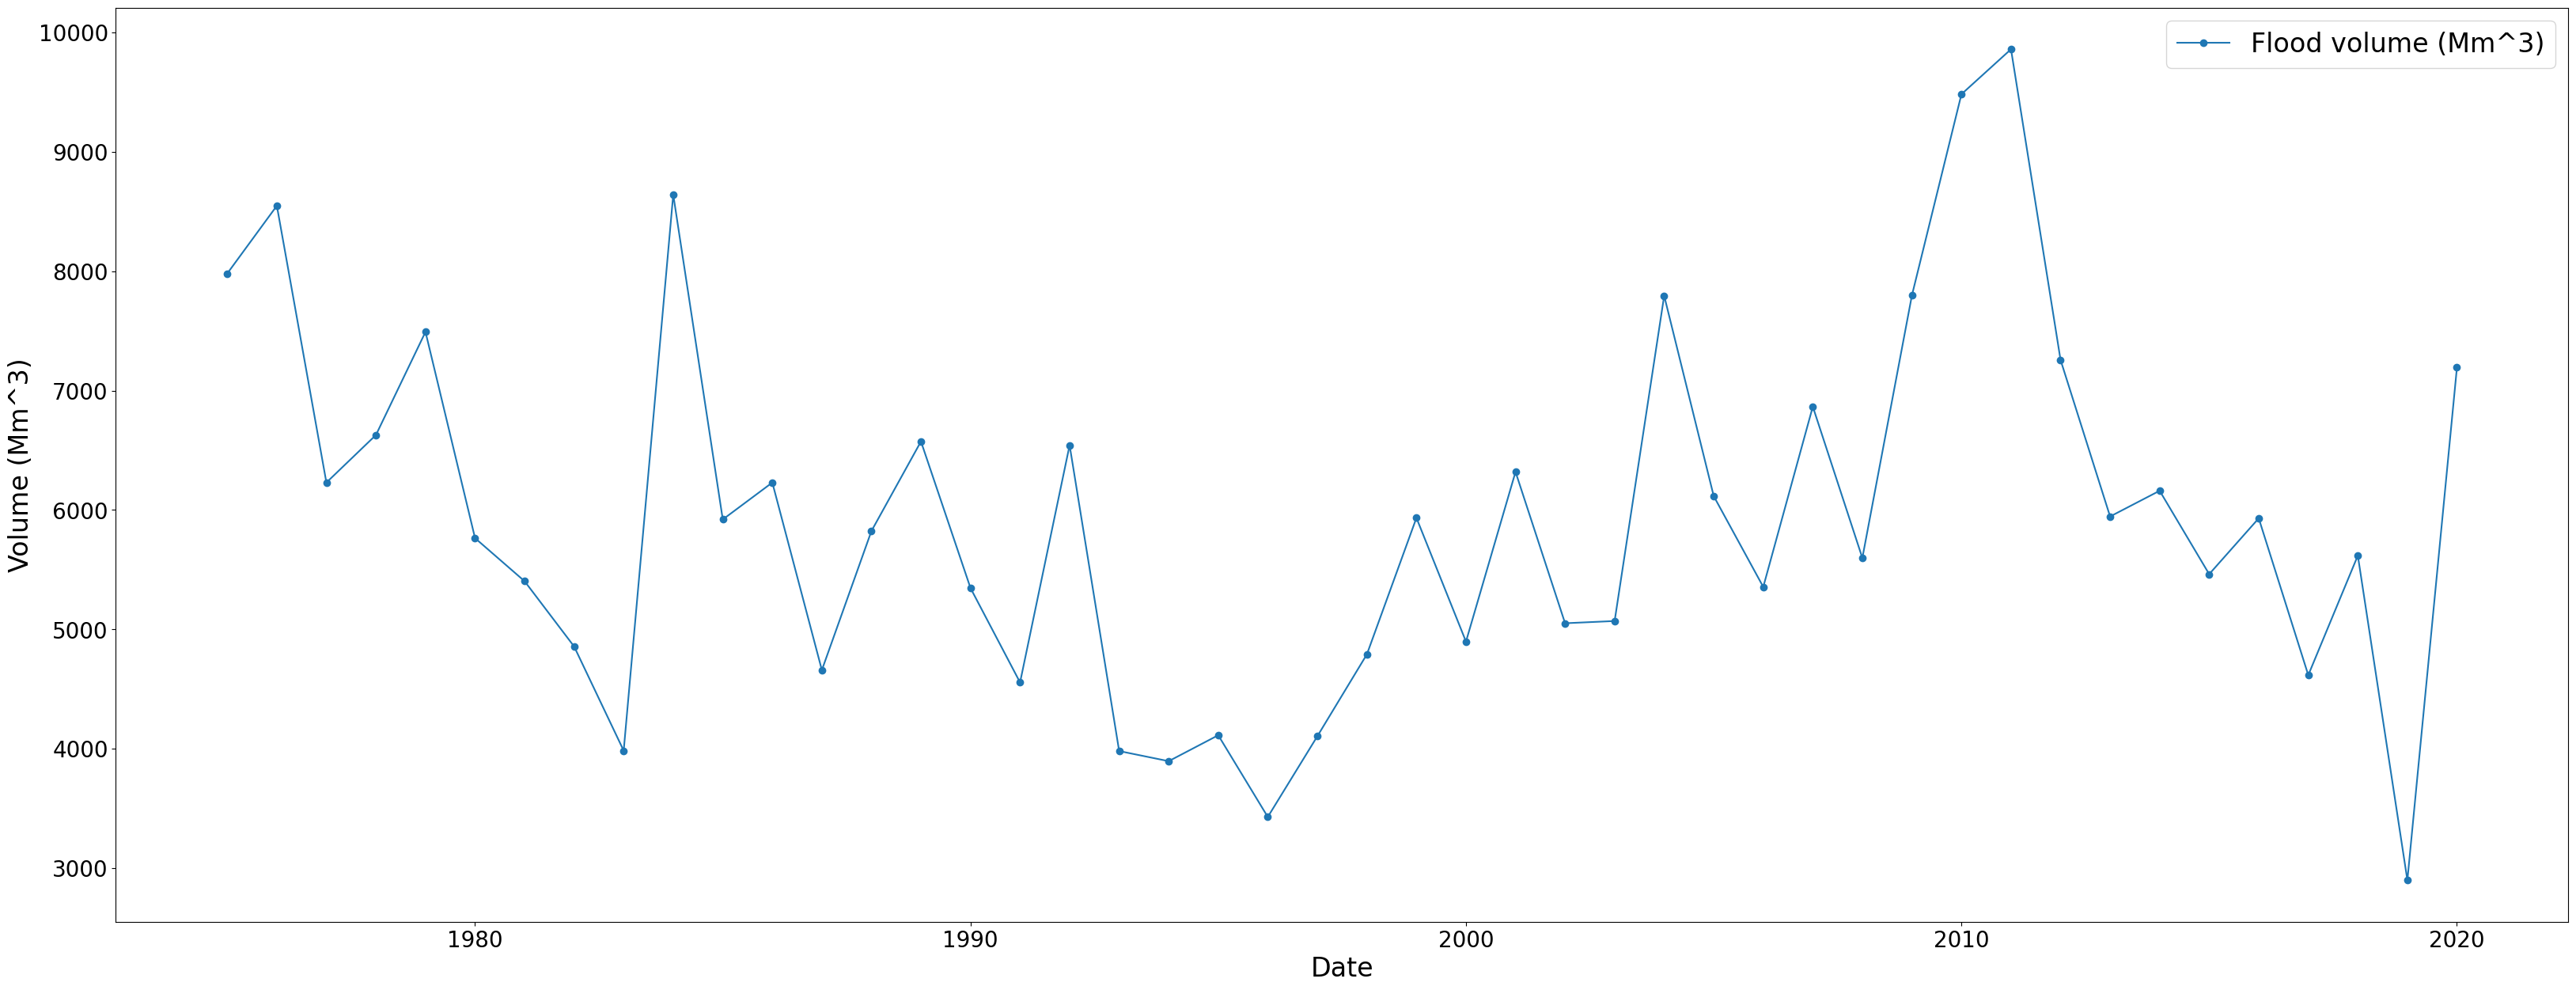

In [7]:
flood_volume = (data_daily * 3600 * 24)[data_daily.index.month.isin([2,3,4,5,6,7])].resample("YE").sum() / 1e6
flood_volume.index = flood_volume.index.year
flood_volume.columns = ['Flood volume (Mm^3)']

fig, ax = plt.subplots(figsize=(40, 15))
flood_volume.plot(ax=ax, marker='o')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24);

Plotting yearly volume and flood volume

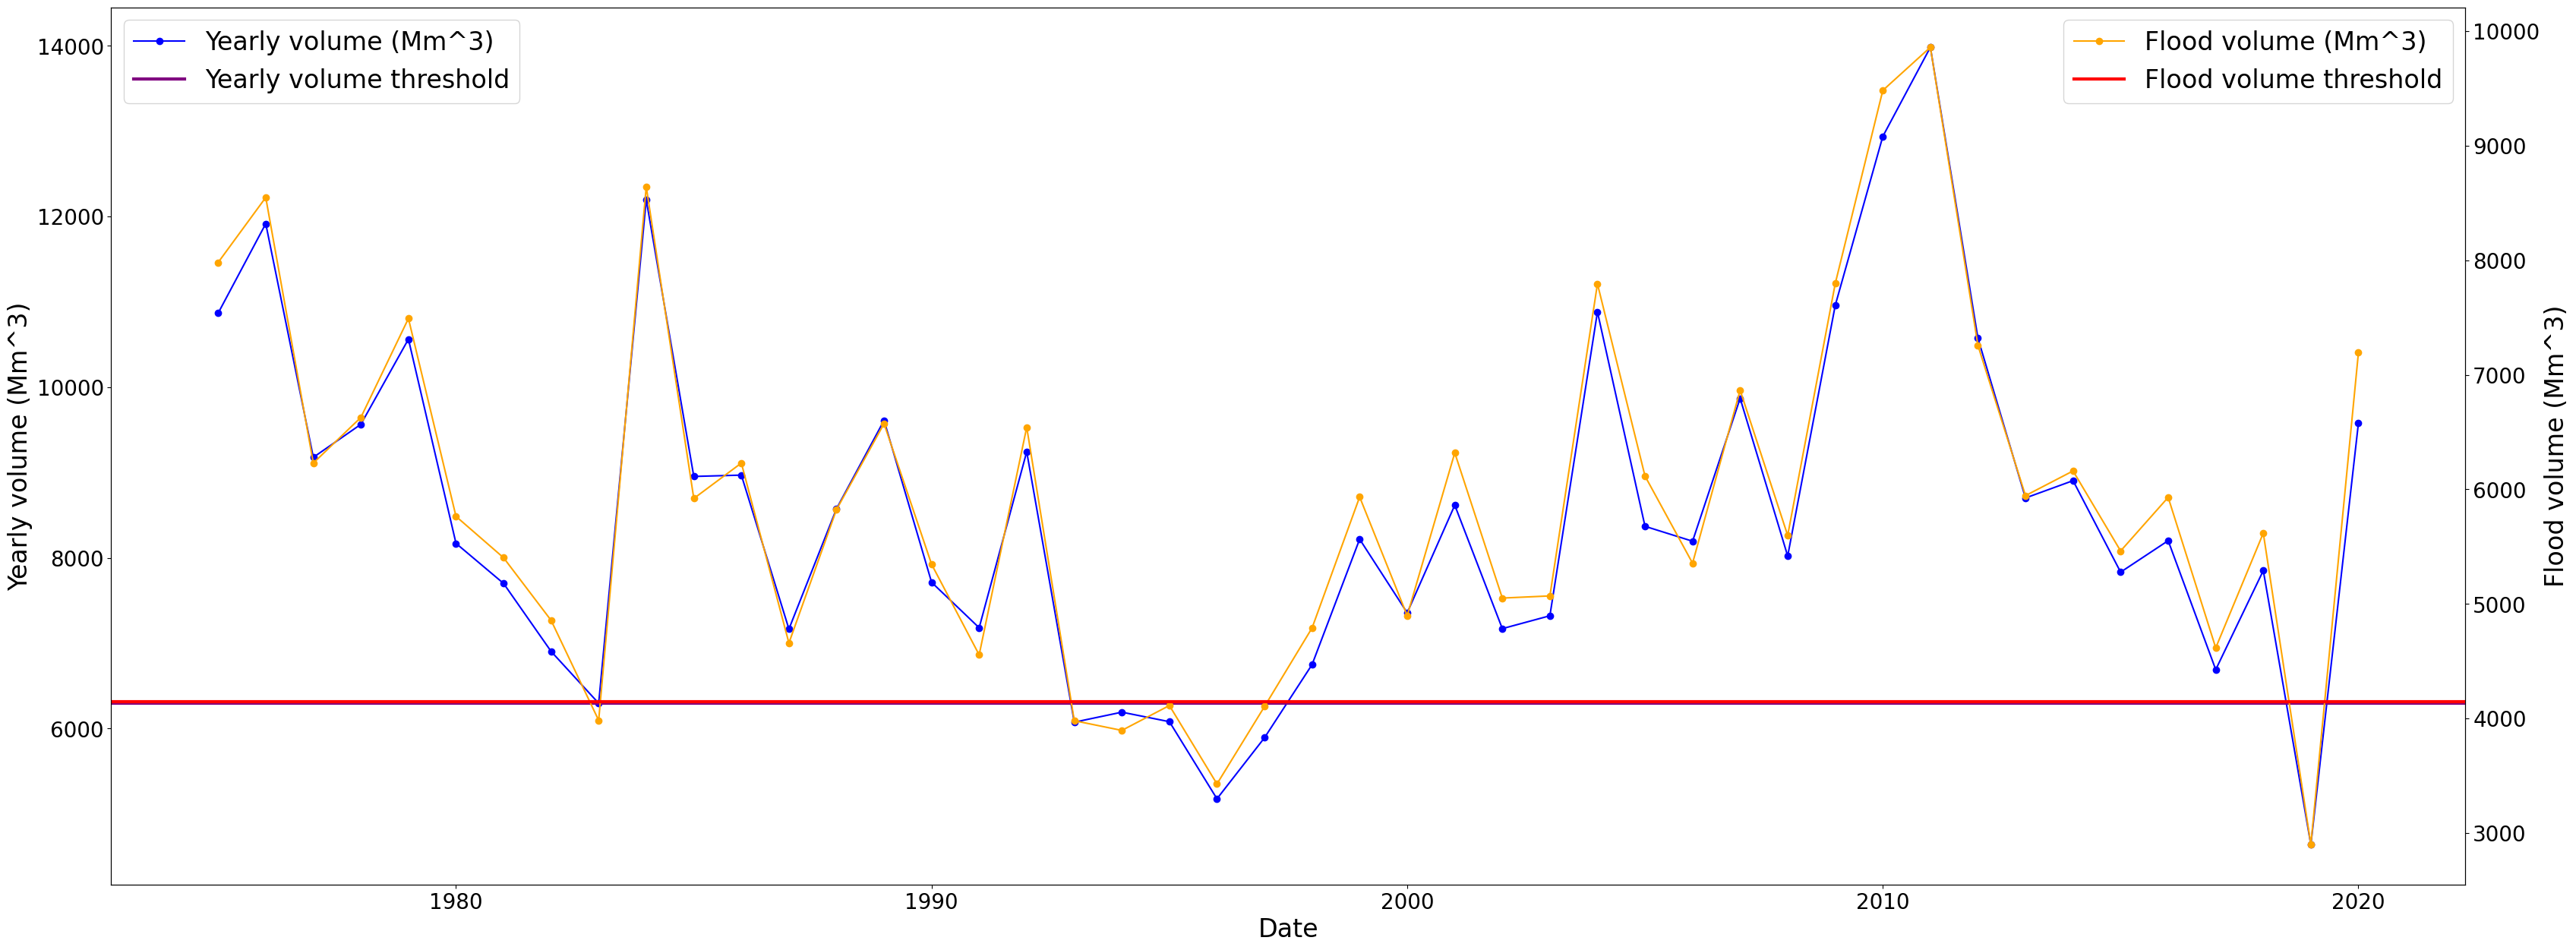

In [8]:
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
yearly_volume.plot(ax=ax, marker='o', color='blue')
plt.axhline(y=6300, color='purple', linewidth=3, label='Yearly volume threshold')
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24, loc='upper left')

ax1 = ax.twinx()
flood_volume.plot(ax=ax1, marker='o', color='orange')
plt.axhline(y=4150, color='red', linewidth=3, label='Flood volume threshold')
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Flood volume (Mm^3)", fontsize=24);

Plotting yearly volume and yearly max discharge

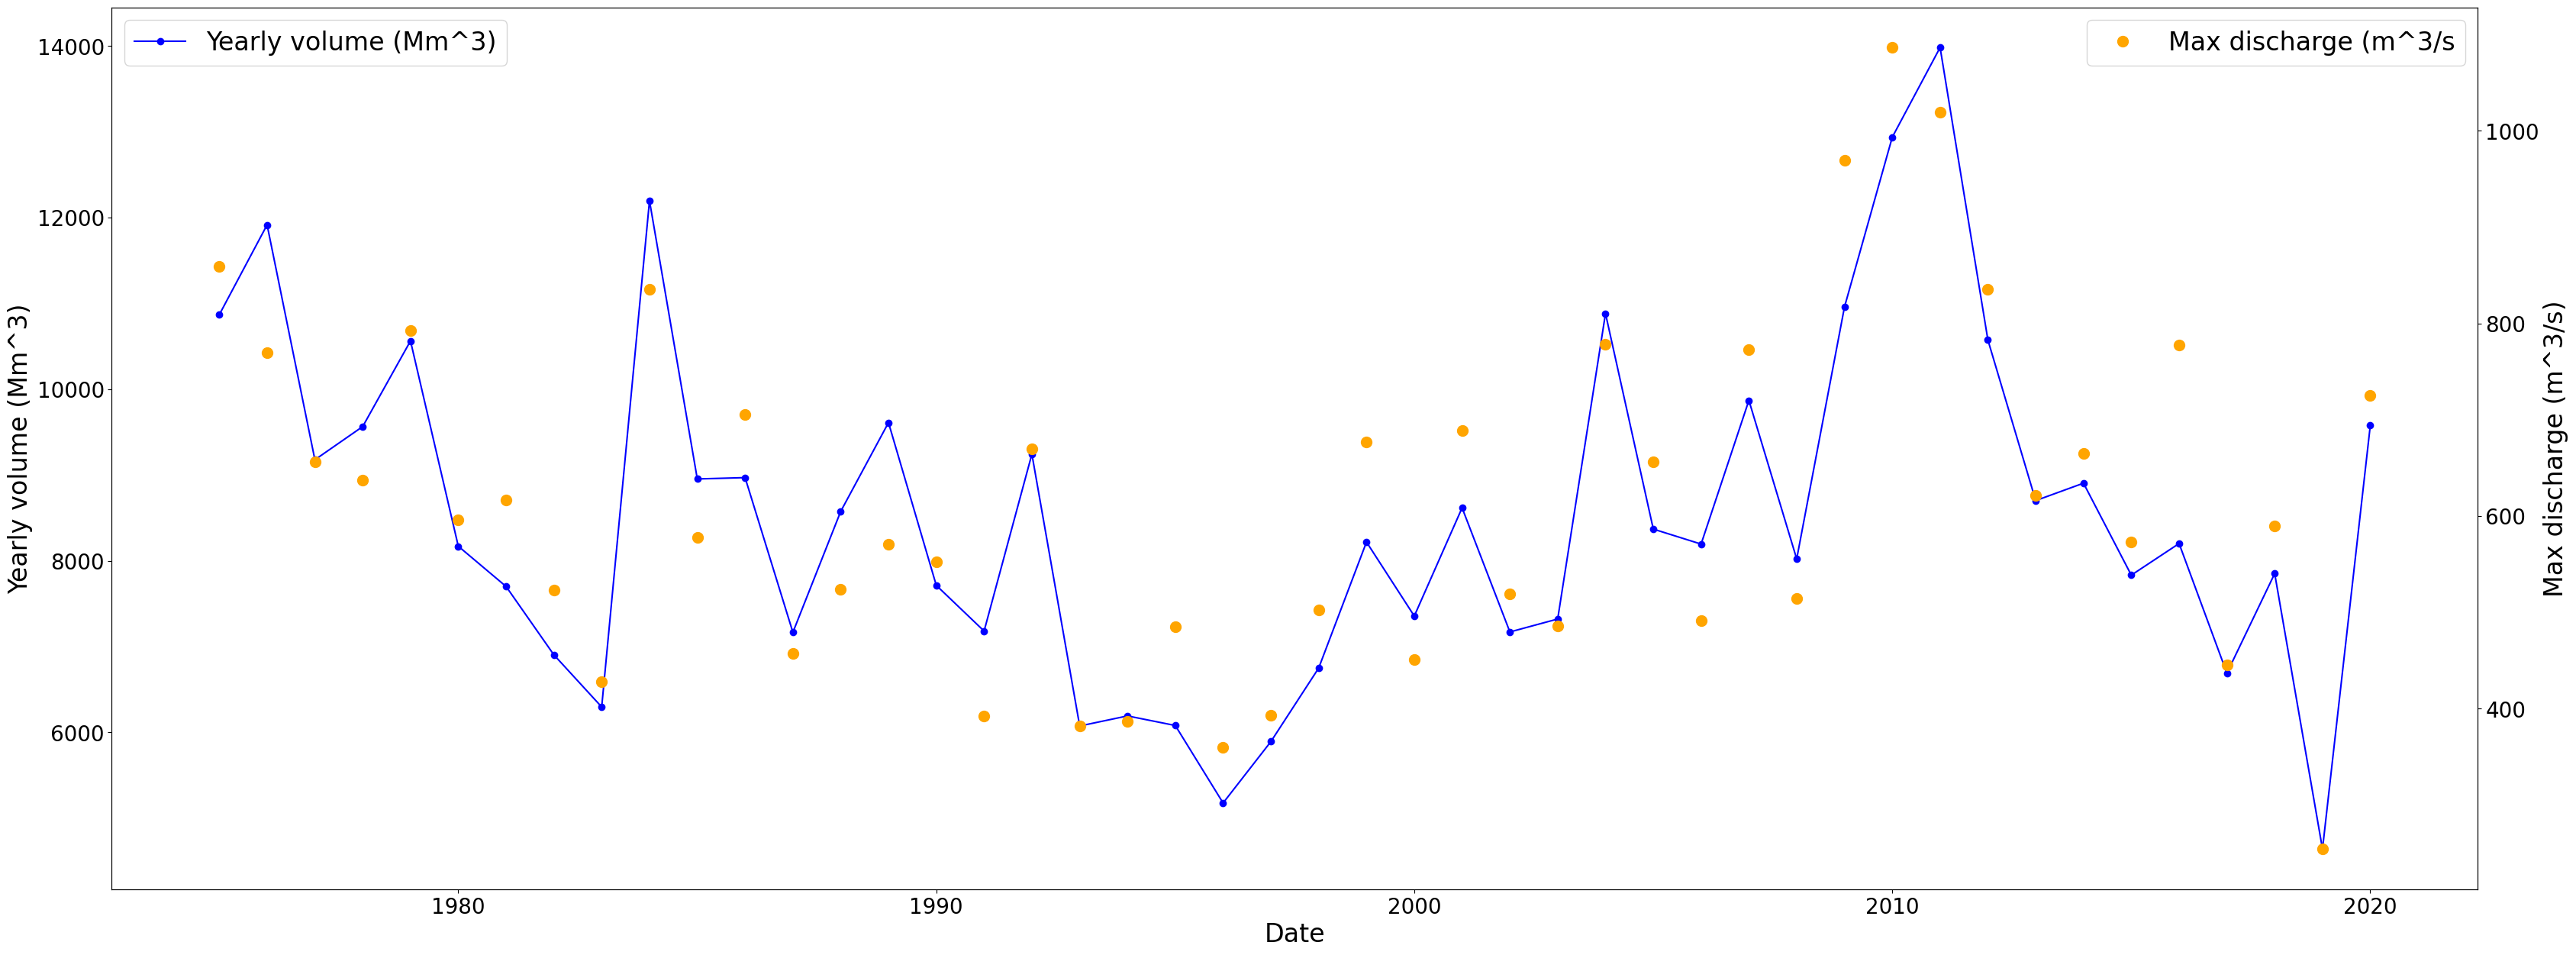

In [9]:
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
yearly_volume.plot(ax=ax, marker='o', color='blue')
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24, loc='upper left')

ax1 = ax.twinx()
yearly_max.plot(ax=ax1, marker='o', color='orange', linestyle='None', markersize=10)
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Max discharge (m^3/s)", fontsize=24);

Plotting flood volume and yearly max

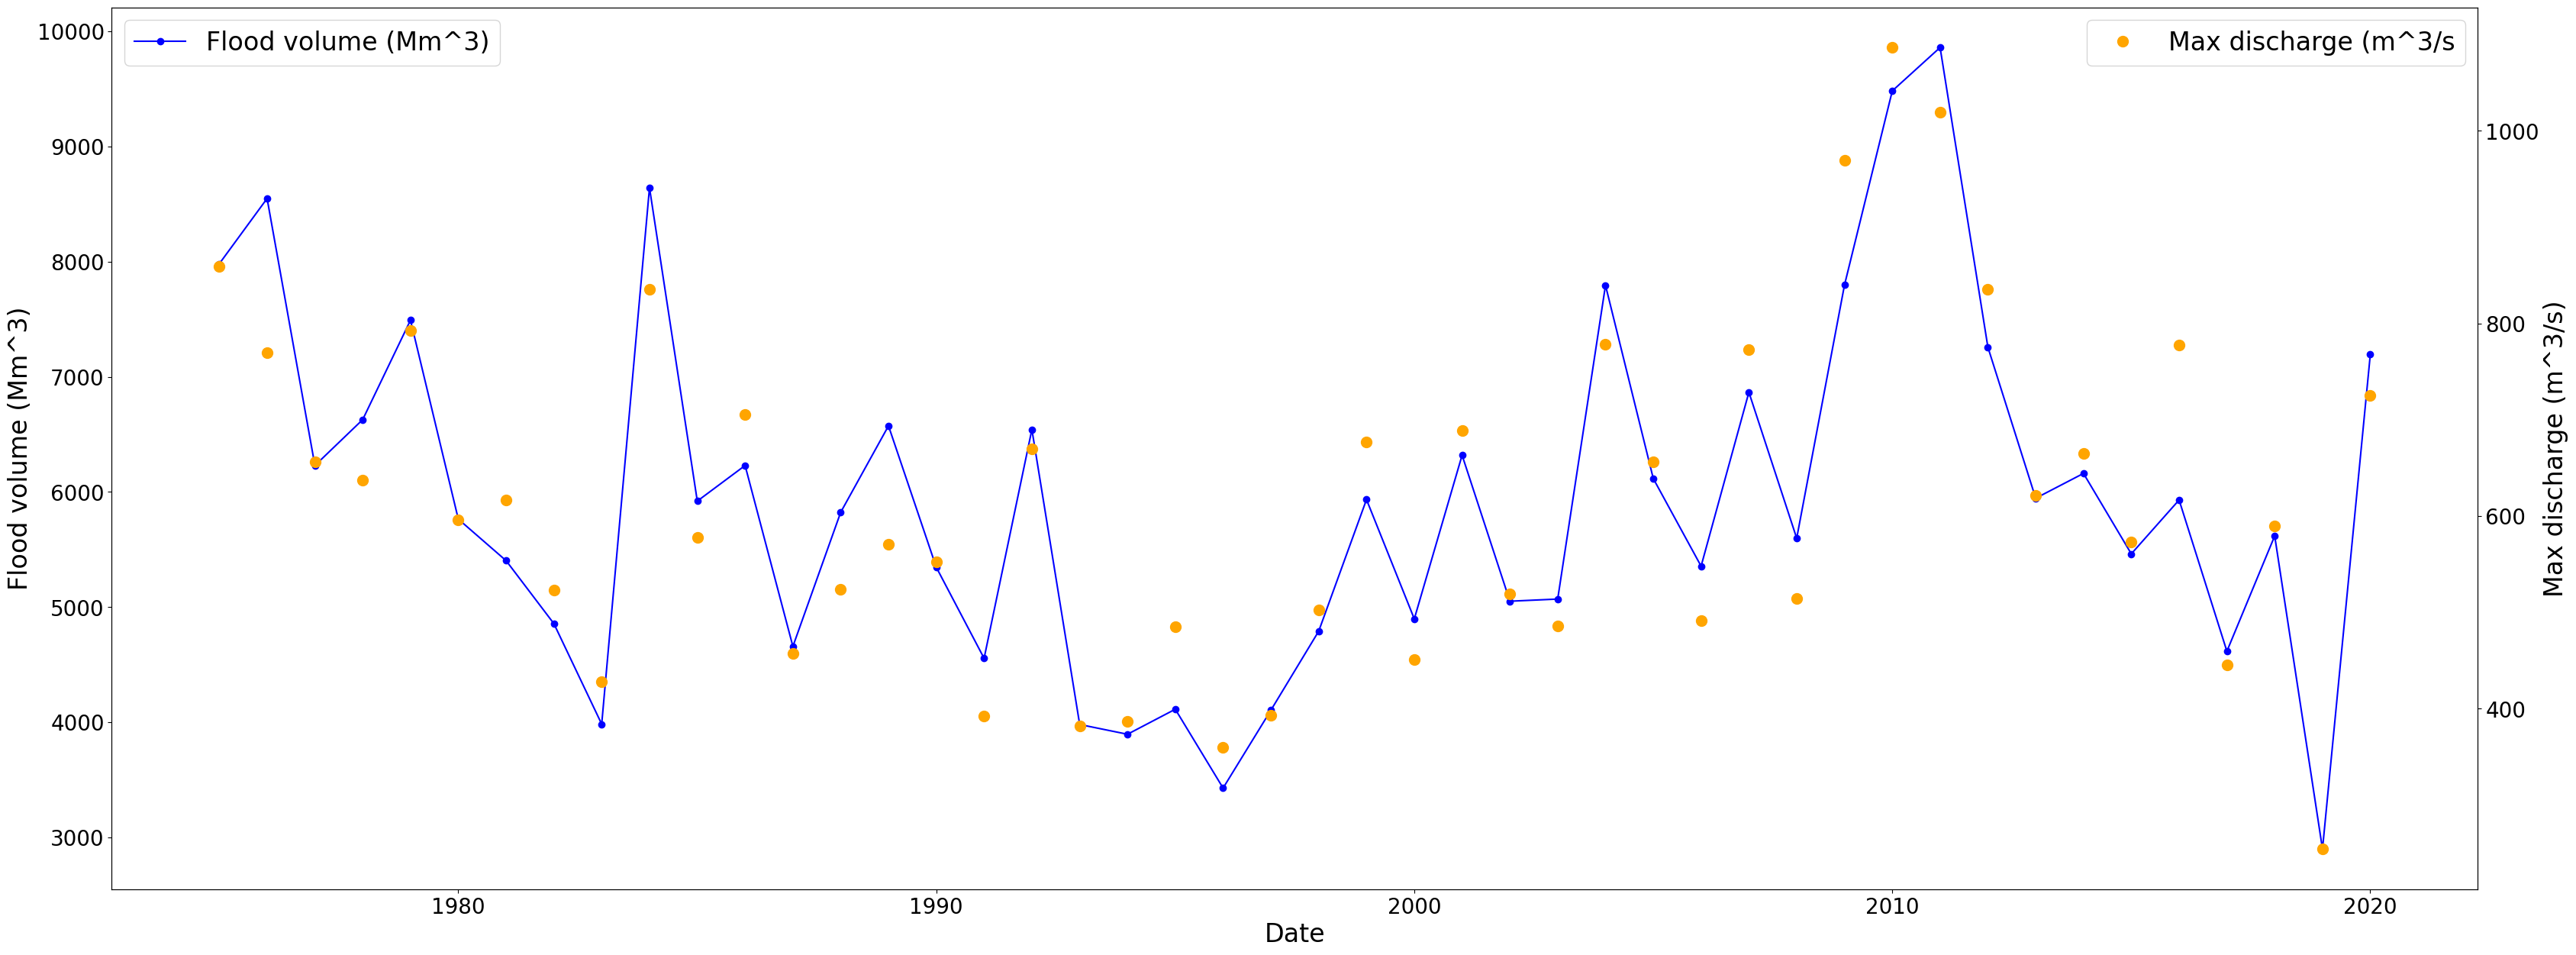

In [10]:
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
flood_volume.plot(ax=ax, marker='o', color='blue')
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
plt.legend(fontsize=24, loc='upper left')

ax1 = ax.twinx()
yearly_max.plot(ax=ax1, marker='o', color='orange', linestyle='None', markersize=10)
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Flood volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Max discharge (m^3/s)", fontsize=24);

Detemining threshold values

In [11]:
a = yearly_max[(yearly_max < 0)]
a = a.dropna()

b = yearly_volume[(yearly_volume < 6300)]
b = b.dropna()

c = flood_volume[(flood_volume < 4150)]
c = c.dropna()

abc = pd.concat([a, b, c], axis=1).sort_index()
abc

,Max discharge (m^3/s,Yearly volume (Mm^3),Flood volume (Mm^3)
date,,,
1983,NaN,6295.129812,3983.992678
1993,NaN,6073.525584,3980.780208
1994,NaN,6190.942493,3896.100000
1995,NaN,6079.328381,4113.261216
1996,NaN,5175.877018,3428.873856
1997,NaN,5891.672592,4104.730512
2019,NaN,4638.847870,2899.341276


Determining historical return period for yearly volume

In [12]:
yearly_volume = yearly_volume.sort_values(by='Yearly volume (Mm^3)', ascending=True)
yearly_volume["I"] = np.arange(1, 47)
yearly_volume["N"] = len(yearly_volume)
yearly_volume["p"] = yearly_volume["I"] / (yearly_volume["N"] + 1)
yearly_volume["q"] = 1 - yearly_volume["p"]
yearly_volume["T"] = 1 / yearly_volume["p"]
yearly_volume["y"] = -np.log(-np.log(yearly_volume["q"]))

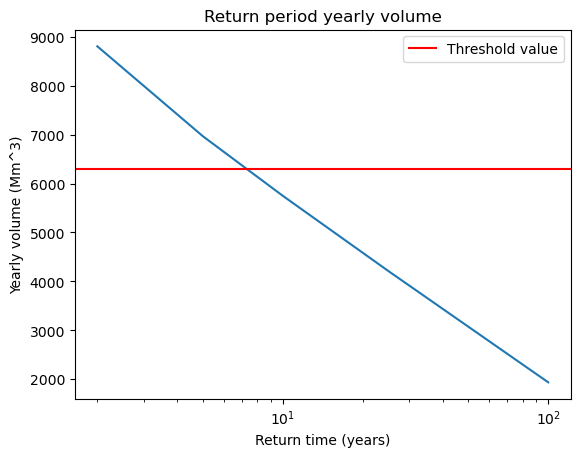

In [13]:
slope, intercept = np.polyfit(yearly_volume["y"], yearly_volume["Yearly volume (Mm^3)"], 1)
returntimes = [2, 5, 10, 25, 100]

y = []
for i in returntimes:
    p = 1 / i
    q = 1 - p
    y.append(-np.log(-np.log(q)))

y = np.array(y)
f = slope * y + intercept

plt.plot(returntimes, f)
plt.axhline(y=6300, label='Threshold value', color= 'red')
plt.xscale("log")
plt.title('Return period yearly volume')
plt.xlabel('Return time (years)')
plt.ylabel('Yearly volume (Mm^3)')
plt.legend();

Detemining historical return period for flood volume

In [14]:
flood_volume = flood_volume.sort_values(by='Flood volume (Mm^3)', ascending=True)
flood_volume["I"] = np.arange(1, 47)
flood_volume["N"] = len(flood_volume)
flood_volume["p"] = flood_volume["I"] / (flood_volume["N"] + 1)
flood_volume["q"] = 1 - flood_volume["p"]
flood_volume["T"] = 1 / flood_volume["p"]
flood_volume["y"] = -np.log(-np.log(flood_volume["q"]))

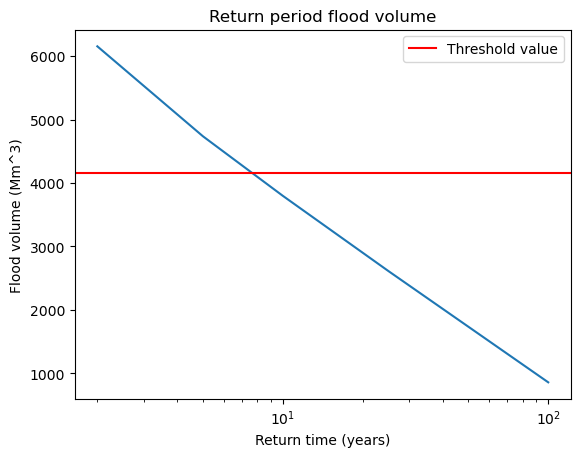

In [15]:
slope, intercept = np.polyfit(flood_volume["y"], flood_volume["Flood volume (Mm^3)"], 1)
returntimes = [2, 5, 10, 25, 100]

y = []
for i in returntimes:
    p = 1 / i
    q = 1 - p
    y.append(-np.log(-np.log(q)))

y = np.array(y)
f = slope * y + intercept

plt.plot(returntimes, f)
plt.axhline(y=4150, label='Threshold value', color= 'red')
plt.xscale("log")
plt.title('Return period flood volume')
plt.xlabel('Return time (years)')
plt.ylabel('Flood volume (Mm^3)')
plt.legend();

Mean annual flow

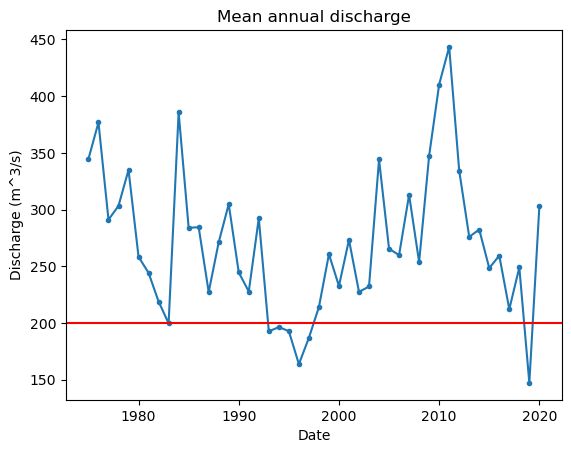

In [16]:
mean_flow = data_daily.resample("YE").mean()
mean_flow.index = mean_flow.index.year
mean_flow.plot(legend=False, marker='o', markersize=3)
plt.axhline(y=200, color='red')
plt.xlabel("Date")
plt.ylabel("Discharge (m^3/s)")
plt.title("Mean annual discharge");